In [1]:
%config Completer.use_jedi = False
import tensorflow as tf
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import os, sys
import time
sys.path.append(os.path.join(os.getcwd(), '../common'))
from utils import timer, save, load

2022-12-10 21:44:13.931365: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
print(f'tensorflow: {tf.__version__}, pandas: {pd.__version__}, numpy: {np.__version__}')

tensorflow: 1.15.0, pandas: 1.1.5, numpy: 1.19.5


## data load

In [25]:
TRADE_MONEY_DIR = os.path.join(os.getcwd(), f'../DataStore/trade_money/')

In [26]:
df_trade_money = pd.DataFrame()
for _file in os.listdir(TRADE_MONEY_DIR):
    df_trade_money_tmp = load(f'{TRADE_MONEY_DIR}/{_file}')
    df_trade_money = pd.concat([df_trade_money, df_trade_money_tmp])

In [27]:
df_trade_money.shape

(2127013, 29)

In [11]:
df_trade_money.head(2)

,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,...,buy_lg_vol,buy_lg_amount,sell_lg_vol,sell_lg_amount,buy_elg_vol,buy_elg_amount,sell_elg_vol,sell_elg_amount,net_mf_vol,net_mf_amount
0,000001.SZ,20221201,13.38,13.66,13.07,13.1,13.03,0.07,0.5372,2002688.83,...,616878.0,81901.71,567369.0,75360.24,549962.0,73323.99,548948.0,72777.05,-52556.0,-6735.42
1,000002.SZ,20221201,18.37,19.14,18.33,19.0,18.65,0.35,1.8767,1719254.89,...,488580.0,91752.61,437556.0,82247.08,354690.0,66756.82,265982.0,49919.04,105528.0,20216.91


## LSTM策略

In [19]:
import matplotlib.pyplot as plt
from numpy import newaxis
from tensorflow.keras.layers import Dense, Activation, Dropout, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras import optimizers

In [30]:
df_trade_money_000001 = df_trade_money[df_trade_money.ts_code == '000001.SZ'].sort_values("trade_date")

df_trade_money_000001.head(2)


,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,...,buy_lg_vol,buy_lg_amount,sell_lg_vol,sell_lg_amount,buy_elg_vol,buy_elg_amount,sell_elg_vol,sell_elg_amount,net_mf_vol,net_mf_amount
1873,000001.SZ,20210104,19.1,19.10,18.44,18.60,19.34,-0.74,-3.8263,1554216.43,...,400970.0,74631.88,546624.0,101737.66,306872.0,57112.03,345477.0,64222.51,-312682.0,-58000.12
912,000001.SZ,20210105,18.4,18.48,17.80,18.17,18.60,-0.43,-2.3118,1821352.10,...,498814.0,89994.05,513429.0,92615.16,266510.0,48051.89,413725.0,74546.48,-329008.0,-59121.70


In [49]:
class conf:
    instrument = '000300.HIX'  #股票代码
    #设置用于训练和回测的开始/结束日期
    start_date = '2005-01-01'  
    end_date='2018-07-19'
    field='close'
    seq_len=7 #每个input的长度
    prediction_len=7 #预测数据长度
    train_proportion=0.9 #训练数据占总数据量的比值，其余为测试数据
    normalise=True #数据标准化
    epochs  = 1 #LSTM神经网络迭代次数
    batch=128 #整数，指定进行梯度下降时每个batch包含的样本数,训练时一个batch的样本会被计算一次梯度下降，使目标函数优化一步
    validation_split=0.1 # 0~1之间的浮点数，用来指定训练集的一定比例数据作为验证集。
    lr=0.001 #学习效率

In [58]:
def load_data(df, seq_len, prediction_len,
              train_proportion, normalise = True):
    datetime = list(df['trade_date'])
    data = list(df["close"])
    seq_len = seq_len + 1
    result = []
    for index in range(len(data) - seq_len):
        result.append(data[index: index + seq_len])
    
    if normalise:
        norm_result = normalise_windows(result)
    else:
        norm_result = result
    
    result=np.array(result)
    norm_result=np.array(norm_result)
    
    row=round(train_proportion*norm_result.shape[0])
    
    data_test=result[int(row):,:]
    datetime=datetime[int(row):]

    test_datetime=[]
    for index in range(len(datetime)):
        if index % prediction_len==0 and index+seq_len<len(datetime)-prediction_len:
            test_datetime.append(datetime[index+seq_len])
    
    train=norm_result[:int(row),:]
#     np.random.shuffle(train)   #随机打乱训练样本
    x_train = train[:, :-1]
    y_train = train[:, -1]
    x_test = norm_result[int(row):, :-1]
    y_test = norm_result[int(row):, -1]
    
    x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
    x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))  

    return [x_train, y_train, x_test, y_test, data_test, test_datetime]

def normalise_windows(window_data):
    normalised_data = []
    for window in window_data:
        normalise_window = [float(p) / float(window[0]) - 1 for p in window]
        normalised_data.append(normalise_window)
    return normalised_data

def denormalise_windows(normdata,data,seq_len):
    #数据反规范化
    denormalised_data = []
    wholelen=0
    for i, rowdata in enumerate(normdata):
        denormalise=list()
        if isinstance(rowdata,float)|isinstance(rowdata,np.float32):
            denormalise = [(rowdata+1)*float(data[wholelen][0])]
            denormalised_data.append(denormalise)
            wholelen=wholelen+1
        else:       
            for j in range(len(rowdata)):
                denormalise.append((float(rowdata[j])+1)*float(data[wholelen][0]))
                wholelen=wholelen+1
            denormalised_data.append(denormalise)
    return denormalised_data

In [38]:
def build_model(layers):
    model = Sequential()
    model.add(LSTM(layers[1],input_shape=(layers[1],layers[0]),return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(layers[1],return_sequences=False))
    model.add(Dropout(0.2))
    
    model.add(Dense(1))
    model.add(Activation("linear"))

    rms=optimizers.RMSprop(lr=conf.lr, rho=0.9, epsilon=1e-06)
    model.compile(loss="mse", optimizer=rms)
    start = time.time()
    print("> Compilation Time : ", time.time() - start)
    return model

In [39]:
def predict_point_by_point(model, data):
    # predict one point at a time
    predicted = model.predict(data)
    predicted = np.shape(predicted, (predicted.size,))
    return predicted

def predict_sequence_full(model, data, seq_len):
    curr_frame = data[0]
    predicted = []
    for i in range(len(data)):
        predicted.append(mode.predict(curr_frame[newaxis,:,:])[0,0])
        curr_frame = curr_frame[1:]
        curr_frame = np.insert(curr_frame, [seq_len-1], predicted[-1], axis = 0)
    return predicted


def predict_sequences_multiple(model, data, seq_len, prediction_len):
    #根据训练模型和每段用来预测的时间序列长度逐步预测prediction_len长度的序列
    prediction_seqs = []
    for i in range(int(len(data)/prediction_len)):
        curr_frame = data[i*prediction_len]
        predicted = []
        for j in range(prediction_len):
            predicted.append(model.predict(curr_frame[newaxis,:,:])[0,0])
            curr_frame = curr_frame[1:]
            curr_frame = np.insert(curr_frame, [seq_len-1], predicted[-1], axis=0)
        prediction_seqs.append(predicted)
    return prediction_seqs

def plot_results(predicted_data, true_data):
    #做图函数，用于predict_point_by_point和predict_sequence_full
    fig = plt.figure(facecolor='white')
    ax = fig.add_subplot(111)
    ax.plot(true_data, label='True Data')
    plt.plot(predicted_data)
    plt.legend()
    figure=plt.gcf()
    figure.set_size_inches(20,10)
    plt.show()

def plot_results_multiple(predicted_data, true_data, prediction_len):
    #做图函数，用于predict_sequences_multiple
    fig = plt.figure(facecolor='white')
    ax = fig.add_subplot(111)
    ax.plot(true_data, label='True Data')
    for i, data in enumerate(predicted_data):
        padding = [None for p in range(i * prediction_len)]
        plt.plot(padding + data)    
    plt.legend()
    figure=plt.gcf()
    figure.set_size_inches(20,10)
    plt.show()

In [42]:
df_trade_money_000001.shape

(464, 29)

In [53]:
df_trade_money_000001.head(10)

,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,...,buy_lg_vol,buy_lg_amount,sell_lg_vol,sell_lg_amount,buy_elg_vol,buy_elg_amount,sell_elg_vol,sell_elg_amount,net_mf_vol,net_mf_amount
1873,000001.SZ,20210104,19.10,19.10,18.44,18.60,19.34,-0.74,-3.8263,1554216.43,...,400970.0,74631.88,546624.0,101737.66,306872.0,57112.03,345477.0,64222.51,-312682.0,-58000.12
912,000001.SZ,20210105,18.40,18.48,17.80,18.17,18.60,-0.43,-2.3118,1821352.10,...,498814.0,89994.05,513429.0,92615.16,266510.0,48051.89,413725.0,74546.48,-329008.0,-59121.70
861,000001.SZ,20210106,18.08,19.56,18.00,19.56,18.17,1.39,7.6500,1934945.12,...,511550.0,96299.50,515372.0,97130.64,668592.0,126532.63,362829.0,68234.79,536918.0,101604.09
33,000001.SZ,20210107,19.52,19.98,19.23,19.90,19.56,0.34,1.7382,1584185.30,...,460759.0,90474.18,416499.0,81737.24,456887.0,89931.80,384793.0,75642.87,50635.0,10246.80
339,000001.SZ,20210108,19.90,20.10,19.31,19.85,19.90,-0.05,-0.2513,1195473.22,...,350307.0,68824.34,320376.0,62932.00,250413.0,49229.27,276820.0,54291.28,-38686.0,-7429.18
2513,000001.SZ,20210111,20.00,20.64,20.00,20.38,19.85,0.53,2.6700,1790457.14,...,604750.0,123390.51,527339.0,107568.58,515718.0,105168.88,410829.0,83738.75,37851.0,7923.34
12,000001.SZ,20210112,20.39,21.00,20.18,21.00,20.38,0.62,3.0422,1288165.50,...,497007.0,102469.43,415937.0,85803.67,391682.0,81200.23,302334.0,62373.00,109331.0,22913.27
717,000001.SZ,20210113,21.00,21.01,20.40,20.70,21.00,-0.30,-1.4286,1049119.73,...,357634.0,73710.34,294954.0,60805.77,247250.0,50973.93,301270.0,62042.75,-249004.0,-51134.24
1284,000001.SZ,20210114,20.68,20.89,19.95,20.17,20.70,-0.53,-2.5604,1130155.62,...,324419.0,66223.66,408114.0,83292.55,286437.0,58472.36,274227.0,55805.84,-101208.0,-20492.95
1140,000001.SZ,20210115,21.00,21.95,20.82,21.00,20.17,0.83,4.1150,2480688.98,...,1003642.0,214865.18,819322.0,175403.57,789568.0,169370.77,766045.0,163960.15,324226.0,70106.22


In [61]:
X_train[0]

array([[ 0.        ],
       [-0.02311828],
       [ 0.0516129 ],
       [ 0.06989247],
       [ 0.0672043 ],
       [ 0.09569892],
       [ 0.12903226]])

In [55]:
18.17 / 18.60 - 1

-0.02311827956989243

In [63]:
print('> Loading data... ')

X_train,y_train,X_test,y_test,data_test,test_datetime = \
    load_data(df_trade_money_000001, conf.seq_len, conf.prediction_len,
              conf.train_proportion, normalise = True)

print('> Data Loaded. Compiling...')
print(X_train.shape)
model = build_model([1, conf.seq_len, 1])

model.fit(
    X_train,
    y_train,
    batch_size=conf.batch,
    nb_epoch=conf.epochs,
    validation_split=conf.validation_split)

> Loading data... 
> Data Loaded. Compiling...
(410, 7, 1)
> Compilation Time :  0.0
Train on 369 samples, validate on 41 samples
369/369 [==============================] - 3s 8ms/sample - loss: 0.0033 - val_loss: 7.9583e-04


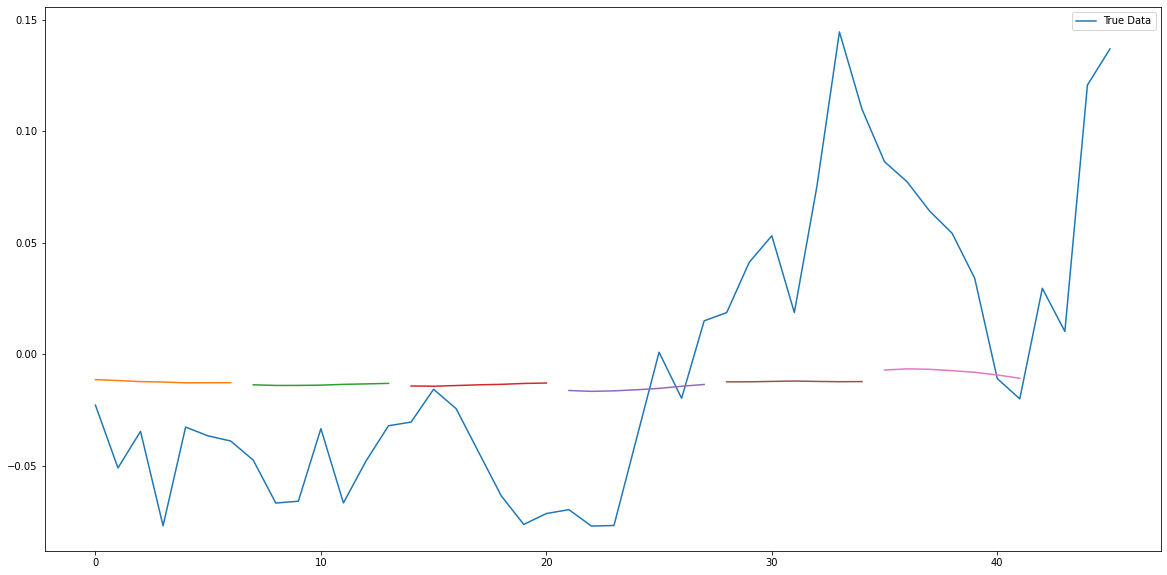

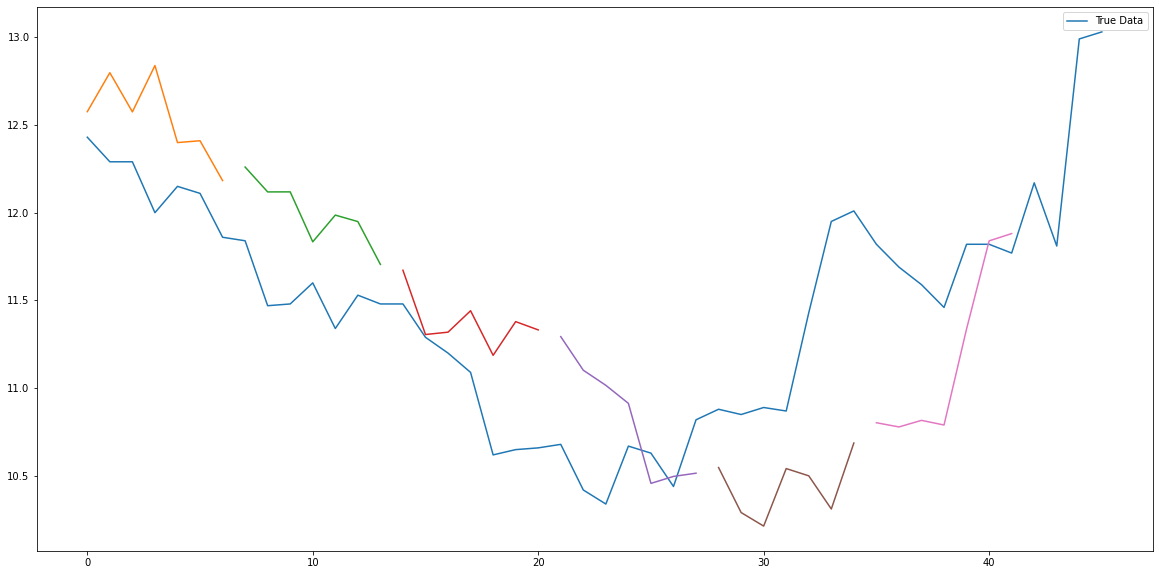

In [64]:
predictions = predict_sequences_multiple(model, X_test, conf.seq_len, conf.prediction_len)
# predictions = predict_sequence_full(model, X_test, conf.seq_len)
# predictions = predict_point_by_point(model, X_test)  
plot_results_multiple(predictions, y_test, conf.prediction_len)

if conf.normalise==True:   
    predictions=denormalise_windows(predictions,data_test,conf.seq_len)
    y_test=denormalise_windows(y_test,data_test,conf.seq_len)

plot_results_multiple(predictions, y_test, conf.prediction_len)

In [41]:
len(predictions)


NameError: name 'predictions' is not defined